In [1]:
import sys, os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))

import pandas as pd
import matplotlib.pyplot as plt

from data_cleaning import (
    load_raw, add_flags, fill_missing_metadata,
    fill_discount_bruto, fill_residual_discount_bruto
)

## 1. Data Loading and Cleaning

Dataset: 283,533 transactions, 6 SKUs, 12 warehouses, ~25 months (Jan 2025 - Jan 2027).

Cleaning rules are implemented in `src/data_cleaning.py` and summarized step by step below.

In [2]:
df = load_raw("../data/20260806_prueba_tecnica_dataset.csv")
print(f"Total rows: {len(df)}")

df = add_flags(df)
print(f"Cancelled tickets: {df['is_cancelled'].sum()}")
print(f"Gifts/samples: {df['is_gift'].sum()}")

df = fill_missing_metadata(df)
df = fill_discount_bruto(df)
df = fill_residual_discount_bruto(df)

print("\nRemaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Total rows: 283533
Cancelled tickets: 500
Gifts/samples: 500

Remaining nulls:
id_combo        215544
combo           215544
bruto                1
product_cost       110
dtype: int64


**Decision:** both row types are kept (not dropped), marked with a flag.
- `is_cancelled`: excluded from any demand aggregation (Challenge A).
- `is_gift`: counts as physical demand (Challenge A), but excluded from
  effective price / elasticity calculations (Challenge B), since unit_price=0
  is not a real market price.

**Decision:** the row with missing metadata (category, subcategory, brand,
basket) was filled by mapping from other rows with the same `product_code`,
since these fields are constant per SKU. No row was dropped.

**Decision:** `discount`, `bruto`, and `sell_in_amount` are algebraically
related: `bruto = sell_in_amount / (1 - discount)`. Most missing values were
resolved by deriving one column from the other two. Organic sales
(`id_combo` null) with a remaining null default to `discount = 0`.

For 3 rows that belonged to a promotion but had both values missing,
`discount` was imputed with the average discount of that same `id_combo`.
One row remains null in `bruto`: a gift transaction (`amount=0`,
`discount=1.0`) where the formula is mathematically undefined (division by
zero) — left null rather than forcing an arbitrary value.

In [3]:
from data_cleaning import fill_product_cost

df = fill_product_cost(df)
print("Remaining nulls in product_cost:", df["product_cost"].isnull().sum())
print("Imputed rows:", df["product_cost_imputed"].sum())

Remaining nulls in product_cost: 0
Imputed rows: 110


**Decision:** unit cost is NOT constant per SKU over the full period — it's a
step function driven by periodic supplier cost updates. Missing `product_cost`
was imputed using the median unit cost of that SKU **within the same
year-month**, avoiding cross-period contamination.

## 2. Exploratory Analysis: Weekly Demand by SKU

In [4]:
demand = df[~df["is_cancelled"]].copy()
demand["week"] = demand["date"].dt.to_period("W").dt.start_time

weekly_demand = (
    demand.groupby(["product_name", "week"])["sell_in_quantity"]
    .sum()
    .reset_index()
)

weekly_demand.head()

,product_name,week,sell_in_quantity
0,Antitranspirante 150 ml C,2025-01-06,380
1,Antitranspirante 150 ml C,2025-01-13,374
2,Antitranspirante 150 ml C,2025-01-20,434
3,Antitranspirante 150 ml C,2025-01-27,371
4,Antitranspirante 150 ml C,2025-02-03,350


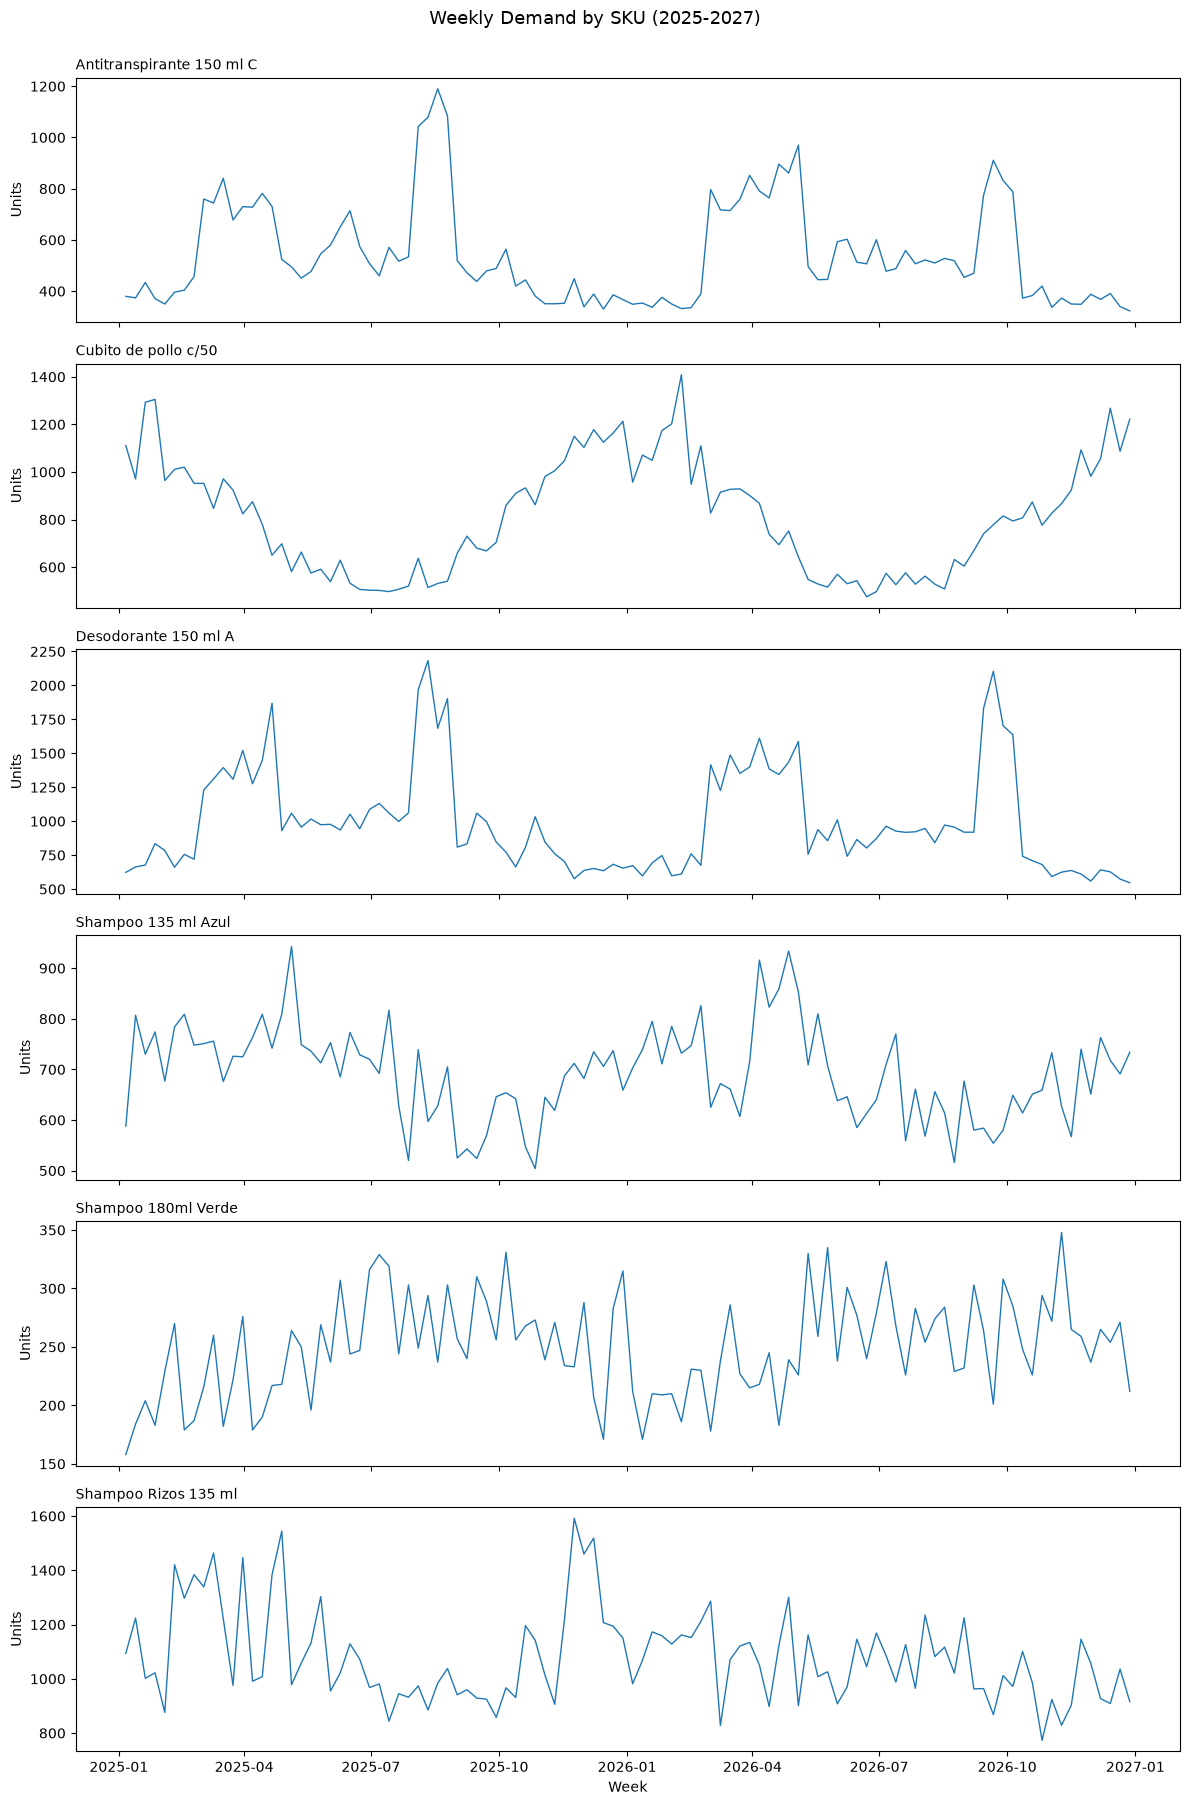

In [5]:
skus = weekly_demand["product_name"].unique()

fig, axes = plt.subplots(len(skus), 1, figsize=(12, 3 * len(skus)), sharex=True)

for ax, sku in zip(axes, skus):
    data = weekly_demand[weekly_demand["product_name"] == sku]
    ax.plot(data["week"], data["sell_in_quantity"], linewidth=1)
    ax.set_title(sku, fontsize=10, loc="left")
    ax.set_ylabel("Units")

axes[-1].set_xlabel("Week")
fig.suptitle("Weekly Demand by SKU (2025-2027)", fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig("../outputs/weekly_demand_by_sku.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Challenge A: Demand Forecasting

Selected SKUs: Desodorante 150 ml A, Cubito de pollo c/50, Shampoo Rizos 135 ml
(chosen for contrasting patterns: strong seasonality, trend+seasonality, and
noisier/harder-to-forecast demand, respectively).

**Validation strategy:** last 10 weeks held out as test set (walk-forward,
no random split — avoids future information leakage). Baseline compared
against more sophisticated models.

In [6]:
selected_skus = ["Desodorante 150 ml A", "Cubito de pollo c/50", "Shampoo Rizos 135 ml"]

forecast_data = weekly_demand[weekly_demand["product_name"].isin(selected_skus)].copy()
forecast_data = forecast_data.sort_values(["product_name", "week"])

TEST_WEEKS = 10

for sku in selected_skus:
    n_weeks = forecast_data[forecast_data["product_name"] == sku].shape[0]
    print(f"{sku}: {n_weeks} weeks total")

Desodorante 150 ml A: 104 weeks total
Cubito de pollo c/50: 104 weeks total
Shampoo Rizos 135 ml: 104 weeks total


### 3.1 Baseline: Seasonal Naive

Predicts demand as equal to the same week, 52 weeks prior — respects the
annual seasonality observed in the EDA. This is the floor any more
sophisticated model must beat.

In [9]:
import numpy as np
def train_test_split_series(df_sku, test_weeks=TEST_WEEKS):
    df_sku = df_sku.sort_values("week").reset_index(drop=True)
    train = df_sku.iloc[:-test_weeks]
    test = df_sku.iloc[-test_weeks:]
    return train, test


def seasonal_naive_forecast(train, test, season_length=52):
    history = train["sell_in_quantity"].values
    preds = []
    for i in range(len(test)):
        idx = len(history) - season_length + i
        preds.append(history[idx] if idx >= 0 else np.nan)
    return np.array(preds)


results = {}
for sku in selected_skus:
    df_sku = forecast_data[forecast_data["product_name"] == sku]
    train, test = train_test_split_series(df_sku)
    preds = seasonal_naive_forecast(train, test)
    results[sku] = {"train": train, "test": test, "seasonal_naive_preds": preds}

for sku in selected_skus:
    print(sku, "-> test actual:", results[sku]["test"]["sell_in_quantity"].values[:3], "...")
    print(sku, "-> naive preds: ", results[sku]["seasonal_naive_preds"][:3], "...")

Desodorante 150 ml A -> test actual: [681 592 625] ...
Desodorante 150 ml A -> naive preds:  [1033  847  760] ...
Cubito de pollo c/50 -> test actual: [776 827 867] ...
Cubito de pollo c/50 -> naive preds:  [ 862  981 1005] ...
Shampoo Rizos 135 ml -> test actual: [773 924 829] ...
Shampoo Rizos 135 ml -> naive preds:  [1142 1014  906] ...


**Observation:** the seasonal naive baseline overpredicts Desodorante's
test-period demand (e.g. 1033 vs actual 681 in the first test week). A likely
explanation: promotional timing shifted between years — the 2026 "Cierre
Trimestre" combo ran Sep-Oct, ending right before this test window, while the
equivalent period 52 weeks prior had different promo timing. Seasonal naive
cannot account for promo activity, since it only copies last year's value
blindly. This motivates trying a model that can incorporate a promo flag as
a feature.

In [10]:
def mape(actual, pred):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

def wmape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual)) * 100

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred) ** 2))


baseline_metrics = []
for sku in selected_skus:
    actual = results[sku]["test"]["sell_in_quantity"].values
    pred = results[sku]["seasonal_naive_preds"]
    baseline_metrics.append({
        "sku": sku,
        "MAPE": mape(actual, pred),
        "WMAPE": wmape(actual, pred),
        "RMSE": rmse(actual, pred),
    })

baseline_df = pd.DataFrame(baseline_metrics)
print(baseline_df)

                    sku       MAPE      WMAPE        RMSE
0  Desodorante 150 ml A  18.762656  18.933552  155.641897
1  Cubito de pollo c/50  10.712028  10.196001  111.587634
2  Shampoo Rizos 135 ml  31.613514  31.656051  336.114266


**Baseline results (Seasonal Naive):**

| SKU | MAPE | WMAPE | RMSE |
|---|---|---|---|
| Desodorante 150 ml A | 18.8% | 18.9% | 155.6 |
| Cubito de pollo c/50 | 10.7% | 10.2% | 111.6 |
| Shampoo Rizos 135 ml | 31.6% | 31.7% | 336.1 |

Error ranks as expected from the EDA: Cubito (clear pattern) < Desodorante
(promo-timing sensitive) < Shampoo Rizos (noisiest). This ordering is the
floor a more sophisticated model must beat, ideally by the largest margin on
Desodorante, where a promo-aware model should have the most to gain.

### 3.2 Model 1: XGBoost

Chosen first because it can incorporate a promo-activity flag as a feature —
directly addressing the gap identified in the baseline (seasonal naive
cannot see promotions). Features: lags (1, 2, 52 weeks), month, week-of-year,
and promo flag/discount depth.

In [12]:
demand["has_promo"] = demand["id_combo"].notnull()

weekly_promo = (
    demand.groupby(["product_name", "week"])
    .agg(
        sell_in_quantity=("sell_in_quantity", "sum"),
        has_promo=("has_promo", "max"),           # 1 si al menos una venta esa semana fue con promo
        avg_discount=("discount", "mean"),
    )
    .reset_index()
)

weekly_promo.head(10)

,product_name,week,sell_in_quantity,has_promo,avg_discount
0,Antitranspirante 150 ml C,2025-01-06,380,False,-0.000161
1,Antitranspirante 150 ml C,2025-01-13,374,False,0.004233
2,Antitranspirante 150 ml C,2025-01-20,434,False,0.000114
3,Antitranspirante 150 ml C,2025-01-27,371,False,0.000231
4,Antitranspirante 150 ml C,2025-02-03,350,False,0.000131
5,Antitranspirante 150 ml C,2025-02-10,396,False,0.003938
6,Antitranspirante 150 ml C,2025-02-17,404,False,0.000167
7,Antitranspirante 150 ml C,2025-02-24,457,False,0.000005
8,Antitranspirante 150 ml C,2025-03-03,760,True,0.153601
9,Antitranspirante 150 ml C,2025-03-10,744,True,0.153677


**Note:** `avg_discount` is not exactly 0 in non-promo weeks (e.g. -0.000161)
— this is floating-point noise inherited from the discount imputation step
in `data_cleaning.py`, not a data quality issue. It's negligible (~1e-4
magnitude) and does not affect the promo flag (`has_promo`), which is based
on `id_combo` presence, not on the discount value itself.

**Validation:** `has_promo` correctly flips to `True` exactly at 2025-03-03,
matching the "Combo Verano Antitranspirante" start date from the combo
summary table, with demand jumping from 457 to 760 units that same week —
confirms the weekly aggregation and promo flag are correctly aligned.

In [13]:
def build_features(df_sku):
    df_sku = df_sku.sort_values("week").reset_index(drop=True)
    df_sku["lag_1"] = df_sku["sell_in_quantity"].shift(1)
    df_sku["lag_2"] = df_sku["sell_in_quantity"].shift(2)
    df_sku["lag_52"] = df_sku["sell_in_quantity"].shift(52)
    df_sku["month"] = df_sku["week"].dt.month
    df_sku["week_of_year"] = df_sku["week"].dt.isocalendar().week.astype(int)
    return df_sku

featured = []
for sku in selected_skus:
    df_sku = weekly_promo[weekly_promo["product_name"] == sku].copy()
    df_sku = build_features(df_sku)
    featured.append(df_sku)

featured_data = pd.concat(featured, ignore_index=True)

print(featured_data.shape)
print(featured_data.isnull().sum())

(312, 10)
product_name          0
week                  0
sell_in_quantity      0
has_promo             0
avg_discount          0
lag_1                 3
lag_2                 6
lag_52              156
month                 0
week_of_year          0
dtype: int64


**Decision:** `lag_52` was dropped as a feature. With only 94 training weeks
per SKU, requiring `lag_52` would cut the training set roughly in half (156
of 312 rows are null, since the entire first year has no "52 weeks prior"
data to reference). `month` and `week_of_year` are kept instead — they
capture the same seasonal signal (time of year) without depending on a
single noisy value from exactly one year back, and without sacrificing half
the already-limited training data.

`lag_1` and `lag_2` nulls (3 and 6 rows respectively, one per SKU at the
start of its series) are negligible and dropped directly.

### 3.3 Model 2: SARIMA

A classical statistical model using only the series' own past values (no
external regressors). Included as a second comparison to check whether a
simpler, promo-blind model still performs competitively.